In [ ]:
%pip install -U --quiet numpy>=2.0 pandas>=2.2 scipy>=1.11 scikit-learn>=1.5 shap>=0.46.0 pygad>=3.2.0 pygam>=0.9.0
# First try interpret (EBM) ; না মিললে GAM fallback থাকবে।
# %pip install -U --quiet interpret



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.2 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.2 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.2 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


[OK] P_ACQ.xpt            -> ACQ        shape=(14149, 6)
[OK] P_ALQ.xpt            -> ALQ        shape=(8965, 10)
[OK] P_AUQ.xpt            -> AUQ        shape=(14986, 58)
[OK] P_BPQ.xpt            -> BPQ        shape=(10195, 11)
[OK] P_CBQPFA.xpt         -> CBQPFA     shape=(8552, 66)
[OK] P_CBQPFC.xpt         -> CBQPFC     shape=(3567, 72)
[OK] P_CDQ .xpt           -> CDQ        shape=(6433, 17)
[OK] P_DBQ.xpt            -> DBQ        shape=(15560, 46)
[OK] P_DEMO.xpt           -> DEMO       shape=(15560, 29)
[OK] P_DEQ.xpt            -> DEQ        shape=(5810, 6)
[OK] P_DIQ.xpt            -> DIQ        shape=(14986, 28)
[OK] P_DPQ.xpt            -> DPQ        shape=(8965, 11)
[OK] P_ECQ.xpt            -> ECQ        shape=(5365, 10)
[OK] P_FSQ.xpt            -> FSQ        shape=(15560, 20)
[OK] P_HEQ.xpt            -> HEQ        shape=(13218, 5)
[OK] P_HIQ.xpt            -> HIQ        shape=(15560, 14)
[OK] P_HSQ.xpt            -> HSQ        shape=(9445, 2)
[OK] P_HUQ.xpt            

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

[SAVE] groupwise_pruned_features.csv
[SAVE] groupwise_ranked_features_full.csv


100% (11 of 11) |########################| Elapsed Time: 0:01:11 Time:  0:01:11
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

[SAVE] domain_importance_ebm.csv


100% (11 of 11) |########################| Elapsed Time: 0:00:15 Time:  0:00:15
100% (11 of 11) |########################| Elapsed Time: 0:00:14 Time:  0:00:14
100% (11 of 11) |########################| Elapsed Time: 0:00:14 Time:  0:00:14
100% (11 of 11) |########################| Elapsed Time: 0:00:07 Time:  0:00:07
100% (11 of 11) |########################| Elapsed Time: 0:00:39 Time:  0:00:39
100% (11 of 11) |########################| Elapsed Time: 0:00:23 Time:  0:00:23
100% (11 of 11) |########################| Elapsed Time: 0:01:08 Time:  0:01:08
100% (11 of 11) |########################| Elapsed Time: 0:00:24 Time:  0:00:24
100% (11 of 11) |########################| Elapsed Time: 0:00:41 Time:  0:00:41
100% (11 of 11) |########################| Elapsed Time: 0:00:03 Time:  0:00:03
100% (11 of 11) |########################| Elapsed Time: 0:00:14 Time:  0:00:14
100% (11 of 11) |########################| Elapsed Time: 0:00:42 Time:  0:00:42
100% (11 of 11) |#######################

[SAVE] ga_domain_selection.json
[SAVE] domain_priority_final.csv

--- Domain importance (perm, pruned subset) ---


,domain,perm_importance,selected_by_GA
0,behavioral-lifestyle,0.126575,1
1,clinical-health,0.118278,1
3,socio-demographic,0.080833,1
2,other,0.004278,1



--- GA selected domains ---
['behavioral-lifestyle', 'clinical-health', 'other', 'socio-demographic']


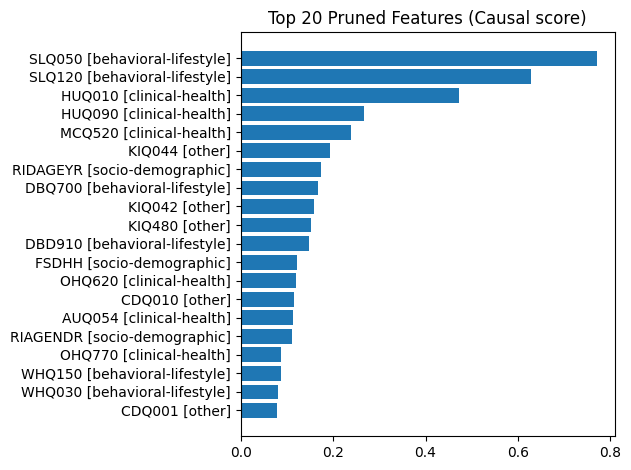

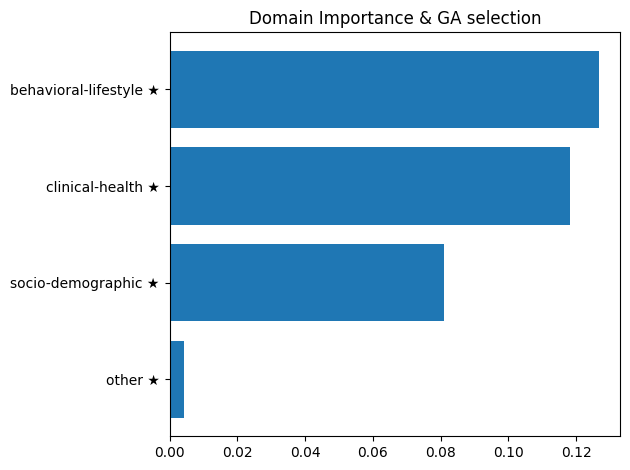

In [ ]:
# ================================
# Domain-First Causal Pipeline (Steps 1–3) — Py3.12 + Low-Memory + Caching
# ================================
import os, re, json, gc, warnings, time
from pathlib import Path
from typing import Dict, List, Tuple
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)

# ---------- Low-memory toggles ----------
LOW_MEM        = True
ROW_SUBSAMPLE  = 15000    # বড় হলে ট্রেনিংয়ের জন্য সর্বোচ্চ রো
SHAP_SAMPLE    = 800      # SHAP-এর জন্য ইনস্ট্যান্স
PI_REPEATS     = 3        # permutation_importance repeat
OHE_MAX_CATS   = 25       # OHE ক্যাটাগরি ক্যাপ
OHE_MIN_FREQ   = 0.02     # rare ক্যাটাগরি কম্বাইন
GA_GENERATIONS = 8        # GA হালকা
GA_POP         = 12

np.random.seed(42)

# ---- Paths ----
CANDIDATES = ["/content/mental_data", "/content/drive/MyDrive/Mental_Dataset/Dataset"]
INPUT_DIR = next((p for p in CANDIDATES if os.path.isdir(p)), None)
if INPUT_DIR is None:
    raise FileNotFoundError("Put .XPT files in /content/mental_data or /content/drive/MyDrive/Mental_Dataset/Dataset")
OUTPUT_DIR = "/content/mental_outputs"; Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
CACHE_DIR  = Path(OUTPUT_DIR)/"cache"; CACHE_DIR.mkdir(parents=True, exist_ok=True)
MERGED_PKL = CACHE_DIR/"merged.pkl"
COLDOM_JSON= CACHE_DIR/"col_domain.json"

# ---- Step 1: Domain-Aware Group Formation ----
DOMAIN_BY_MODULE: Dict[str, str] = {
    # Socio-demographic
    "DEMO":"socio-demographic","INQ":"socio-demographic","HIQ":"socio-demographic",
    "OCQ":"socio-demographic","FSQ":"socio-demographic",
    # Behavioral / Lifestyle
    "ALQ":"behavioral-lifestyle","SMQ":"behavioral-lifestyle","PAQ":"behavioral-lifestyle",
    "SLQ":"behavioral-lifestyle","DBQ":"behavioral-lifestyle","WHQ":"behavioral-lifestyle",
    # Clinical / Health
    "HSQ":"clinical-health","HUQ":"clinical-health","MCQ":"clinical-health","BPQ":"clinical-health",
    "OHQ":"clinical-health","RHQ":"clinical-health","HEQ":"clinical-health","RXQ":"clinical-health",
    "ACQ":"clinical-health","AUQ":"clinical-health",
    # Outcome
    "DPQ":"mental-health-outcome",
}
DPQ_VALID_VALUES = {0,1,2,3}

def infer_module_from_filename(stem: str) -> str:
    s = stem.upper();  return s[2:] if s.startswith("P_") else s

def coarse_module_key(module: str) -> str:
    m = module.upper()
    if m in DOMAIN_BY_MODULE: return m
    parts = m.split("_")
    for p in [parts[0], m[:3], m[:4]]:
        if p in DOMAIN_BY_MODULE: return p
    return parts[0] if parts else m

def assign_domain_from_module(module: str) -> str:
    return DOMAIN_BY_MODULE.get(coarse_module_key(module), "other")

# ---------- helpers: memory ----------
def downcast_numeric(df: pd.DataFrame) -> pd.DataFrame:
    for c in df.select_dtypes(include=["float64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="float")
    for c in df.select_dtypes(include=["int64","int32"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="integer")
    return df

# ---------- person-level aggregation for long modules ----------
# Np.nan add kore
def _mode_agg(s: pd.Series):
    s = s.dropna()
    if s.empty: return np.nan
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]
# convert it into numerical
def _coerce_numeric_if_mostly_numeric(s: pd.Series):
    if pd.api.types.is_object_dtype(s):
        sn = pd.to_numeric(s, errors="coerce")
        if sn.notna().mean() >= 0.8:
            return sn
    return s

# copy and normalization than every column convert it into upercase
def aggregate_module_person_level(df: pd.DataFrame, module: str) -> pd.DataFrame:
    d = df.copy(); d.columns = [str(c).upper() for c in d.columns]
    for c in d.columns:
        if c == "SEQN": continue
        d[c] = _coerce_numeric_if_mostly_numeric(d[c])
    rc = d.groupby("SEQN").size().rename(f"{module}_N").reset_index()
    agg_dict = {c: ("median" if pd.api.types.is_numeric_dtype(d[c]) else _mode_agg)
                for c in d.columns if c!="SEQN"}
    d_agg = d.groupby("SEQN", as_index=False).agg(agg_dict).merge(rc, on="SEQN", how="left")
    return downcast_numeric(d_agg)

# ---------- read & merge ----------
def read_all_xpt(input_dir: str) -> Dict[str, pd.DataFrame]:
    dfs = {}
    for p in sorted(Path(input_dir).glob("*.xpt")):
        module = infer_module_from_filename(p.stem)
        try:
            df = pd.read_sas(p, format="xport", encoding="utf-8")
        except Exception as e:
            print(f"[WARN] Can't read {p.name}: {e}"); continue
        df.columns = [str(c).upper() for c in df.columns]
        if "SEQN" not in df.columns:
            print(f"[INFO] {p.name} has no SEQN; skipped."); continue
        dfs[module] = downcast_numeric(df)
        dup = int(df.duplicated("SEQN").sum())
        print(f"[OK] {p.name:20s} -> {module:10s} shape={tuple(df.shape)}{' (long)' if dup>0 else ''}")
    return dfs

# if there are multiple SEQN value than combine it and get SEQN (Mean)

def merge_modules_person_level(mods: Dict[str,pd.DataFrame]) -> Tuple[pd.DataFrame, Dict[str,str]]:
    if not mods: raise RuntimeError("No modules.")
    start_key = "DEMO" if "DEMO" in mods else next(iter(mods.keys()))
    base = mods[start_key]
    if base.duplicated("SEQN").any():
        base = aggregate_module_person_level(base, start_key)
    merged = base.copy()
    col_domain = {c: assign_domain_from_module(start_key) for c in merged.columns if c!="SEQN"}

    for module, df in mods.items():
        if module == start_key: continue
        df2 = aggregate_module_person_level(df, module) if df.duplicated("SEQN").any() else downcast_numeric(df.copy())
        # avoid collisions
        for c in list(df2.columns):
            if c=="SEQN": continue
            if c in merged.columns:
                newc = f"{c}__{module}"
                df2.rename(columns={c:newc}, inplace=True)
                col_domain[newc] = assign_domain_from_module(module)
            else:
                col_domain[c] = assign_domain_from_module(module)
        merged = pd.merge(merged, df2, on="SEQN", how="outer", validate="one_to_one")
        del df2; gc.collect()
    return downcast_numeric(merged), col_domain


def build_phq9(df: pd.DataFrame) -> pd.DataFrame:
    dpq_cols = [c for c in df.columns if re.fullmatch(r"DPQ0[1-9]0(?:__.*)?", c)]
    if not dpq_cols:
        print("[WARN] No DPQ items found; PHQ-9 cannot be built.")
        out = df.copy(); out["PHQ9_TOTAL"]=np.nan; return out
    def _coerce(s):
        v = pd.to_numeric(s, errors="coerce")
        return v.where(v.isin(list(DPQ_VALID_VALUES)), np.nan)
    mat = pd.DataFrame({c: _coerce(df[c]) for c in dpq_cols})
    out = df.copy(); out["PHQ9_TOTAL"] = mat.sum(axis=1, min_count=1)
    return downcast_numeric(out)

# ----- merge & target (with cache) -----
t0 = time.time()
if MERGED_PKL.exists() and COLDOM_JSON.exists():
    print("[LOAD] merged.pkl + col_domain.json (cached)")
    merged = pd.read_pickle(MERGED_PKL)
    with open(COLDOM_JSON, "r") as f: col_dom = json.load(f)
else:
    mods = read_all_xpt(INPUT_DIR)
    merged, col_dom = merge_modules_person_level(mods)
    merged = build_phq9(merged)
    merged.to_pickle(MERGED_PKL)
    with open(COLDOM_JSON, "w") as f: json.dump(col_dom, f)
    print("[SAVE] merged.pkl + col_domain.json")
json.dump(DOMAIN_BY_MODULE, open(f"{OUTPUT_DIR}/domain_mapping.json","w"), indent=2)
print(f"[INFO] merge+target ready in {time.time()-t0:.1f}s | shape={merged.shape}")

# ---- preprocessing ----
df = merged.copy(); del merged; gc.collect()
y = df["PHQ9_TOTAL"]; mask = y.notna()
df = df.loc[mask].copy(); y = y.loc[mask].astype("float32")

# optional row subsample
if LOW_MEM and ROW_SUBSAMPLE and len(df) > ROW_SUBSAMPLE:
    df = df.sample(n=ROW_SUBSAMPLE, random_state=42)
    y  = y.loc[df.index]
    print(f"[INFO] Row subsample → {len(df)} rows")

drop_patterns = [r"^SEQN$", r"^PHQ9_TOTAL$", r"^DPQ"]
drop_cols = set()
for pat in drop_patterns: drop_cols |= set([c for c in df.columns if re.match(pat, c)])
X = df.drop(columns=list(drop_cols), errors="ignore"); del df; gc.collect()

# keep ≥60% observed
# only 60% value are -  binary column for every unique category and Frequency Cap valid it

X = X.loc[:, X.notna().sum().ge(int(0.6*len(X)))].copy()

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

# OneHot with frequency cap

try:
    ohe = OneHotEncoder(handle_unknown="ignore",
                        min_frequency=OHE_MIN_FREQ, max_categories=OHE_MAX_CATS,
                        sparse_output=False)
except TypeError:  # older/newer API diff
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# convert all the things into numerical (0/1)
prep = ColumnTransformer(
    [("num", SimpleImputer(strategy="median"), num_cols),
     ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", ohe)]), cat_cols)],
    remainder="drop", verbose_feature_names_out=False
)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
del X; gc.collect()


# ---- Step 2: Causal Feature Selection (SHAP → prune) ----
#এটা হলো Step-2: Causal Feature Selection (SHAP → prune)—মানে, মডেল-ভিত্তিক ফিচার গুরুত্ব মেপে (SHAP বা বিকল্পে permutation importance) ডোমেইন-আধারে ফিচার ছাঁটাই করা
reg = HistGradientBoostingRegressor(loss="squared_error", learning_rate=0.08,
                                    max_leaf_nodes=31, random_state=42)
pipe = Pipeline([("prep", prep), ("model", reg)])
pipe.fit(Xtr, ytr)
yhat = pipe.predict(Xte)
print(f"[METRIC] Holdout R2={r2_score(yte,yhat):.3f} | MAE={mean_absolute_error(yte,yhat):.3f}")

feat_proc = pipe.named_steps["prep"].get_feature_names_out().tolist()
def base_name(f): return f.split("_")[0].split("=")[0]

# SHAP with row subsample (fallback to permutation)
#SHAP: ট্রি-এক্সপ্লেইনার দিয়ে প্রতি প্রসেসড ফিচারের গড় |SHAP| (অবসোলিউট) নেওয়া হয় = গুরুত্ব।
try:
    import shap
    Xte_proc_full = pipe.named_steps["prep"].transform(Xte)
    if LOW_MEM and SHAP_SAMPLE and Xte_proc_full.shape[0] > SHAP_SAMPLE:
        idx = np.random.default_rng(42).choice(Xte_proc_full.shape[0], SHAP_SAMPLE, replace=False)
        Xte_proc = Xte_proc_full[idx]
    else:
        Xte_proc = Xte_proc_full
    expl = shap.Explainer(pipe.named_steps["model"], feature_names=feat_proc, algorithm="tree")
    sv = expl(Xte_proc)
    shap_abs = np.abs(sv.values).mean(axis=0)
    imp_df = pd.DataFrame({"feature_proc": feat_proc, "shap_importance": shap_abs})
    imp_df["feature_base"] = imp_df["feature_proc"].map(base_name)
except Exception as e:
    print(f"[WARN] SHAP failed ({e}); using permutation importance (light).")
    res = permutation_importance(pipe, Xte, yte, n_repeats=PI_REPEATS, random_state=42, n_jobs=-1, scoring="r2")
    imp_df = pd.DataFrame({"feature_proc": feat_proc, "shap_importance": res.importances_mean})
    imp_df["feature_base"] = imp_df["feature_proc"].map(base_name)

agg = imp_df.groupby("feature_base", as_index=False)["shap_importance"].sum()
agg["domain"] = agg["feature_base"].map(lambda b: col_dom.get(b, "other"))
agg["group_rel"] = agg.groupby("domain")["shap_importance"].transform(lambda s: s/(s.sum()+1e-9))

PRUNE_REL_THRESHOLD = 0.02 # ডোমেইনে অন্তত ২% অবদান না থাকলে ফিচার বাদ।
TOPK_PER_GROUP = 10 # প্রতিটি ডোমেইনে সর্বোচ্চ ১০টি রেখে দেয়া—এতে কোনো ডোমেইন অতিরিক্ত দখল নিতে পারে না, ডোমেইন-ফেয়ারনেস বজায় থাকে।
keep = (agg.query("group_rel >= @PRUNE_REL_THRESHOLD")
          .sort_values(["domain","shap_importance"], ascending=[True,False])
          .groupby("domain", as_index=False).head(TOPK_PER_GROUP))
keep.to_csv(f"{OUTPUT_DIR}/groupwise_pruned_features.csv", index=False)
agg.sort_values(["domain","shap_importance"], ascending=[True,False]) \
   .to_csv(f"{OUTPUT_DIR}/groupwise_ranked_features_full.csv", index=False)
print("[SAVE] groupwise_pruned_features.csv")
print("[SAVE] groupwise_ranked_features_full.csv")


# ---- Step 3: Domain Prioritization (EBM if available, else GAM) ----
#ExplainableBoostingRegressor (EBM) ইনস্টল থাকলে সেটি নেয়; না থাকলে pyGAM LinearGAM নেয়। দুটোই ব্যাখ্যাযোগ্য (additive) মডেল—ডোমেইন অবদান বুঝতে সুবিধা।
try:
    from interpret.glassbox import ExplainableBoostingRegressor
    EBM_AVAILABLE = True
except Exception:
    from pygam import LinearGAM
    EBM_AVAILABLE = False
import pygad

def cols_for_domains(cols: List[str], domains_selected: List[str]) -> List[str]:
    return [c for c in cols if col_dom.get(c, "other") in domains_selected]
    #এই ফাংশন নির্দিষ্ট ডোমেইন-সাবসেট দিয়ে একটি ছোট, ব্যাখ্যাযোগ্য মডেল ট্রেন করে এবং মেট্রিকস রিটার্ন করে।

def eval_domains(domains_selected: List[str]):
    # use only **pruned base columns** to keep it light
    pruned_cols = set(keep["feature_base"].tolist())
    candidate_cols = [c for c in list(Xtr.columns) if c in pruned_cols and col_dom.get(c,"other") in domains_selected]
    if len(candidate_cols) == 0:
        return {"r2": -np.inf, "mae": np.inf, "n_features": 0}

#Step-2-এর প্রুনড বেস-ফিচার থেকে শুধু নির্বাচিত ডোমেইনের কলাম নেয়। কিছু না পেলে খুব খারাপ স্কোর রিটার্ন (GA যেন এ সল্যুশন বাতিল করে)।
    Xsub_all = pd.concat([Xtr[candidate_cols], Xte[candidate_cols]], axis=0)
    y_all = pd.concat([pd.Series(ytr), pd.Series(yte)], axis=0)

    num = [c for c in Xsub_all.columns if pd.api.types.is_numeric_dtype(Xsub_all[c])]
    cat = [c for c in Xsub_all.columns if c not in num]
    try:
        ohe2 = OneHotEncoder(handle_unknown="ignore",
                             min_frequency=OHE_MIN_FREQ, max_categories=OHE_MAX_CATS,
                             sparse_output=False)
    except TypeError:
        ohe2 = OneHotEncoder(handle_unknown="ignore", sparse=False)
    prep2 = ColumnTransformer(
        [("num", SimpleImputer(strategy="median"), num),
         ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", ohe2)]), cat)],
        remainder="drop", verbose_feature_names_out=False
    )
    Xtr2, Xva2, ytr2, yva2 = train_test_split(Xsub_all, y_all, test_size=0.25, random_state=12)

#রিটার্নে R², MAE, এবং n_features (OHE-এর পরে আসল ইনপুট ডাইমেনশন) দেয়—এটাই GA-র কস্ট টার্মে ব্যবহৃত হবে।
    if EBM_AVAILABLE:
        est = ExplainableBoostingRegressor(random_state=12)
        pipe2 = Pipeline([("prep", prep2), ("model", est)])
        pipe2.fit(Xtr2, ytr2)
        yhat2 = pipe2.predict(Xva2)
        r2 = r2_score(yva2, yhat2); mae = mean_absolute_error(yva2, yhat2)
        n_feat = pipe2.named_steps["prep"].get_feature_names_out().size
        return {"r2": r2, "mae": mae, "n_features": int(n_feat), "model": pipe2, "is_ebm": True}
    else:
        Xtr2p, Xva2p = prep2.fit_transform(Xtr2), prep2.transform(Xva2)
        gam = LinearGAM().gridsearch(Xtr2p, ytr2)
        yhat2 = gam.predict(Xva2p)
        r2 = r2_score(yva2, yhat2); mae = mean_absolute_error(yva2, yhat2)
        n_feat = Xtr2p.shape[1]
        class Dummy:
            def __init__(self, prep, model): self.named_steps={"prep":prep, "model":model}
        return {"r2": r2, "mae": mae, "n_features": int(n_feat), "model": Dummy(prep2, gam), "is_ebm": False}

# 3A) Domain contribution in processed space (pruned subset only)
#সব প্রুনড ডোমেইন একসাথে দিয়ে একটি রেফারেন্স মডেল ট্রেন করা হয় (EBM/GAM যেটাই হোক)।

#তারপর processed features (OHE-এর পরে) স্তরে permutation importance চালানো হয়—R² কত পড়ে তা দিয়ে প্রতিটি প্রসেসড ফিচারের গুরুত্ব পাওয়া যায়।

#প্রসেসড ফিচার নাম থেকে বেস-ফিচার → ডোমেইন ম্যাপ পুনর্গঠন করে ডোমেইনভিত্তিক sum:

all_domains = sorted(set(col_dom.get(c,"other") for c in keep["feature_base"])) \
              or sorted(set(col_dom.get(c,"other") for c in agg["feature_base"]))
pipe_dom = eval_domains(all_domains)["model"]
prep2 = pipe_dom.named_steps["prep"]; est = pipe_dom.named_steps["model"]

# validation slice on pruned columns
pruned_cols_val = [c for c in Xte.columns if c in set(keep["feature_base"]) and col_dom.get(c,"other") in all_domains]
X_eval_base = Xte[pruned_cols_val].copy()
X_eval_proc = prep2.transform(X_eval_base)
feat_names_proc = prep2.get_feature_names_out().tolist()
pi = permutation_importance(est, X_eval_proc, yte, n_repeats=PI_REPEATS, random_state=7, n_jobs=-1, scoring="r2")
assert X_eval_proc.shape[1] == len(feat_names_proc) == len(pi.importances_mean)

dom_of_proc = {fn: col_dom.get(fn.split("_")[0].split("=")[0], "other") for fn in feat_names_proc}
dom_imp = pd.DataFrame({"feature_proc": feat_names_proc, "perm_importance": pi.importances_mean})
dom_imp["domain"] = dom_imp["feature_proc"].map(lambda f: dom_of_proc.get(f, "other"))
dom_summary = dom_imp.groupby("domain", as_index=False)["perm_importance"].sum() \
                     .sort_values("perm_importance", ascending=False)
dom_summary.to_csv(f"{OUTPUT_DIR}/domain_importance_ebm.csv", index=False)
print("[SAVE] domain_importance_ebm.csv")

# 3B) GA (PyGAD ≥2.20: 3-arg fitness)
#GA-তে প্রতিটি ডোমেইন = একটি বাইনারি জিন (0/1)। মোট জিন = D।
import pygad
domain_list = all_domains; D = len(domain_list)
ALPHA, BETA, GAMMA = 1.0, 0.0005, 0.01

def fitness_func(ga_instance, solution, solution_idx):
    bits = [int(round(b)) for b in solution]
    selected = [domain_list[i] for i,b in enumerate(bits) if b==1]
    if not selected: return -1e9
    res = eval_domains(selected)
    if not np.isfinite(res["r2"]): return -1e9
    return float((ALPHA*res["r2"]) - (BETA*res["n_features"]) - (GAMMA*len(selected)))

initial_pop = np.random.randint(0,2,size=(GA_POP, D))
ga = pygad.GA(num_generations=GA_GENERATIONS, num_parents_mating=6,
              fitness_func=fitness_func, sol_per_pop=GA_POP, num_genes=D,
              gene_space=[0,1], gene_type=int, initial_population=initial_pop,
              mutation_probability=0.12, allow_duplicate_genes=True, suppress_warnings=True)
ga.run()
best_sol, best_fitness, _ = ga.best_solution()
best_bits = [int(round(b)) for b in best_sol]
best_domains = [domain_list[i] for i,b in enumerate(best_bits) if b==1]
res_best = eval_domains(best_domains)

ga_out = {
    "domain_list": domain_list,
    "best_domains": best_domains,
    "fitness": float(best_fitness),
    "r2": float(res_best["r2"]), "mae": float(res_best["mae"]),
    "n_features": int(res_best["n_features"])
}
json.dump(ga_out, open(f"{OUTPUT_DIR}/ga_domain_selection.json","w"), indent=2)
print("[SAVE] ga_domain_selection.json")

dom_summary["selected_by_GA"] = dom_summary["domain"].isin(best_domains).astype(int)
dom_summary.to_csv(f"{OUTPUT_DIR}/domain_priority_final.csv", index=False)
print("[SAVE] domain_priority_final.csv")

from IPython.display import display
print("\n--- Domain importance (perm, pruned subset) ---"); display(dom_summary)
print("\n--- GA selected domains ---"); print(best_domains)

# quick viz (light)
plt.figure(); top = keep.sort_values("shap_importance", ascending=False).head(20)
plt.barh((top["feature_base"]+" ["+top["domain"]+"]")[::-1], top["shap_importance"][::-1])
plt.title("Top 20 Pruned Features (Causal score)"); plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR)/"viz_top_pruned_features.png", dpi=200); plt.show()

plt.figure(); ds = dom_summary.sort_values("perm_importance", ascending=False)
lbl = ds["domain"] + ds["selected_by_GA"].map({1:" ★",0:""})
plt.barh(lbl[::-1], ds["perm_importance"][::-1])
plt.title("Domain Importance & GA selection"); plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR)/"viz_domain_priority_final.png", dpi=200); plt.show()




#ডোমেইন-ফার্স্ট ব্যাখ্যাযোগ্যতা: ফিচার নয়, গ্রুপ (ডোমেইন)-কে ইউনিট ধরা—নীতিগত (policy/intervention) সিদ্ধান্তের সাথে সামঞ্জস্যপূর্ণ।

#রোবাস্টনেস: এক-দুটি ফিচার নয়, গ্রুপ জুড়ে সিগনাল—ড্রিফটে টিকে থাকে।

#অপ্টিমাল কমপ্লেক্সিটি: GA ফিটনেসে R² বনাম (#features, #domains) ট্রেড-অফ টিউনেবল—লীন ও জাস্টিফায়েবল মডেল।


In [ ]:
# ================================
# Step 4 — Estimate Treatment Pathway (One-step backtracking)
# ================================
# Goal: For each target severity level, generate per-person minimal actionable changes that
#       reduce predicted PHQ-9 below the next-lower category’s threshold.
#       Actionable = features from selected domains (e.g., behavioral-lifestyle, clinical-health)
# Dependencies (from Steps 1–3 already in memory):
#   - pipe_dom (Pipeline with 'prep' and 'model' from Step 3)
#   - prep2 (the ColumnTransformer used by pipe_dom)
#   - Xtr, Xte, ytr, yte
#   - keep (DataFrame with pruned 'feature_base' and 'domain')
#   - col_dom (dict mapping base feature -> domain)
#   - OUTPUT_DIR
# If any of these are missing, the code falls back to 'pipe' (Step 2) and derives others.

import numpy as np, pandas as pd, json, gc, warnings
from pathlib import Path
from typing import Dict, List, Tuple, Any
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings("ignore", category=UserWarning)

# ---------- Config ----------
ACTIONABLE_DOMAINS = {"behavioral-lifestyle", "clinical-health"}  # domain set allowed to change
CAT_TOPK_TRY       = 3        # try top-K low-risk categories per categorical feature
NUM_TRY_QUANTILES  = [0.1, 0.25, 0.5, 0.75, 0.9]  # candidate anchors for numeric moves
MAX_FEATURE_CHANGES= 4        # per case one-step plan should be sparse
CF_MAX_CASES       = 400      # limit severe/minimal etc. cases for speed
DELTA_MIN_IMPROVE  = 0.05     # minimal predicted drop in PHQ-9 to accept a tweak
RANDOM_STATE       = 17

rng = np.random.default_rng(RANDOM_STATE)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# ---------- Helpers: PHQ-9 severity mapping & targets ----------
def phq9_level(s: pd.Series) -> pd.Series:
    """
    Severity bins adapted to match the requested backtracking ladder:
      - No depression: score == 0
      - Minimal: 1–4
      - Mild: 5–9
      - Moderate: 10–14
      - Severe: >=15  (merging 'moderately severe' and 'severe' into one step)
    """
    bins = [-np.inf, 0, 4, 9, 14, np.inf]
    labels = ["No", "Minimal", "Mild", "Moderate", "Severe"]
    return pd.cut(s.astype(float), bins=bins, labels=labels, right=True, include_lowest=True).astype(str)

def next_lower_threshold(level: str) -> float:
    """
    Returns the maximum PHQ-9 score to be at the *next-lower* severity.
      Severe   -> target <= 14
      Moderate -> target <= 9
      Mild     -> target <= 4
      Minimal  -> target == 0 (i.e., No)
      No       -> already at floor (return -inf so no plan)
    """
    table = {"Severe": 14.0, "Moderate": 9.0, "Mild": 4.0, "Minimal": 0.0, "No": -np.inf}
    return table.get(level, np.inf)

# ---------- Determine environment / fallbacks ----------
# Prefer the Step-3 domain model; fall back to Step-2 pipe if needed.
_model_pipe = None
if "pipe_dom" in globals():
    _model_pipe = pipe_dom
elif "pipe" in globals():
    _model_pipe = pipe
else:
    raise RuntimeError("No trained model pipeline found (pipe_dom / pipe). Run Steps 2–3 first.")

# Compute which raw/base features are actionable
if "keep" in globals():
    pruned_base = set(keep["feature_base"])
else:
    pruned_base = set()

if "col_dom" not in globals():
    col_dom = {}

def _is_actionable(feat: str) -> bool:
    dom = col_dom.get(feat, "other")
    return (feat in pruned_base) and (dom in ACTIONABLE_DOMAINS)

# Pick evaluation slice (we will generate plans on the held-out set using pruned base features if possible)
if "X_eval_base" in globals():
    X_eval = X_eval_base.copy()
else:
    # fallback: use Xte (but restrict to pruned base cols if available)
    if "Xte" not in globals():
        raise RuntimeError("X_eval_base and Xte are not available.")
    if pruned_base:
        cols = [c for c in Xte.columns if c in pruned_base]
        X_eval = Xte[cols].copy()
    else:
        X_eval = Xte.copy()

# y_true for evaluation (must align on index)
if "yte" not in globals():
    raise RuntimeError("yte (true PHQ-9 on test split) not found.")
y_true_eval = yte.loc[X_eval.index].astype(float)

# Determine numeric/categorical split in raw space
num_cols_eval = [c for c in X_eval.columns if pd.api.types.is_numeric_dtype(X_eval[c])]
cat_cols_eval = [c for c in X_eval.columns if c not in num_cols_eval]

# ---------- Risk-aware prototypes for candidate moves ----------
# For categorical features: choose categories that correlate with lower PHQ-9 in training.
def _low_risk_categories(X: pd.DataFrame, y: pd.Series, col: str, topk: int = CAT_TOPK_TRY) -> List[Any]:
    s = X[col].astype("category")
    tmp = pd.DataFrame({"cat": s, "y": y.loc[s.index].astype(float)})
    stat = tmp.groupby("cat", observed=True)["y"].mean().sort_values(ascending=True)
    cats = [idx for idx in stat.index.tolist() if pd.notna(idx)]
    return cats[:topk]

# For numeric features: use quantile anchors with lower average PHQ-9 historically.
def _low_risk_numeric_anchors(X: pd.DataFrame, y: pd.Series, col: str,
                              quants=NUM_TRY_QUANTILES) -> List[float]:
    xs = X[col].astype(float)
    anchors = np.unique(np.quantile(xs.dropna(), quants))
    out = []
    for a in anchors:
        # Build a coarse proxy: how does being near 'a' relate to lower y on avg?
        # Use a narrow band around 'a' (5th percentile width) for stability
        w = np.nanpercentile(np.abs(xs - a), 5)
        if w == 0 or not np.isfinite(w): w = np.nanstd(xs) * 0.1
        mask = (np.abs(xs - a) <= w) & xs.notna()
        if mask.sum() < 20:  # not enough data near the anchor
            continue
        out.append((a, float(y.loc[mask.index][mask].mean())))
    if not out:
        # fallback: just return quantile anchors ordered ascending
        return sorted(list(map(float, anchors)))
    # Return anchors associated with *lower* mean PHQ-9 first
    out_sorted = sorted(out, key=lambda t: t[1])
    return [a for a,_ in out_sorted]

# Build catalogs from training data
X_train_like = Xtr.reindex(columns=X_eval.columns)
y_train_like = ytr.copy()
cat_lowrisk_choices: Dict[str, List[Any]] = {c: _low_risk_categories(X_train_like, y_train_like, c)
                                             for c in cat_cols_eval if _is_actionable(c)}
num_lowrisk_anchors: Dict[str, List[float]] = {c: _low_risk_numeric_anchors(X_train_like, y_train_like, c)
                                               for c in num_cols_eval if _is_actionable(c)}

# ---------- Prediction utility on raw rows ----------
def _predict_from_rows(df_rows: pd.DataFrame) -> np.ndarray:
    if isinstance(_model_pipe, Pipeline):
        return _model_pipe.predict(df_rows)
    elif hasattr(_model_pipe, 'named_steps') and 'prep' in _model_pipe.named_steps and 'model' in _model_pipe.named_steps:
        # This is the Dummy case or a similar structure
        X_proc = _model_pipe.named_steps['prep'].transform(df_rows)
        return _model_pipe.named_steps['model'].predict(X_proc)
    else:
        raise RuntimeError("Unsupported model pipeline structure.")

# ---------- Greedy local counterfactual (one-step ladder) ----------
def one_step_counterfactual(row: pd.Series, y_pred: float, target_ceiling: float,
                            max_changes: int = MAX_FEATURE_CHANGES) -> Tuple[float, List[Tuple[str, Any, Any, float]]]:
    """
    Greedy coordinate descent in raw feature space (limited domains & plausible values).
    Returns (new_pred, changes), where changes is a list of (feature, old_val, new_val, delta_pred).
    """
    if not np.isfinite(target_ceiling) or y_pred <= target_ceiling:
        return y_pred, []

    base = row.to_frame().T  # DataFrame with single row
    cur_pred = float(y_pred)
    changes: List[Tuple[str, Any, Any, float]] = []

    # List actionable features present in this row
    feats_actionable = [c for c in row.index if _is_actionable(c)]

    for _ in range(max_changes):
        best_gain = 0.0
        best_change = None
        trial_best_df = None

        # Try numeric moves
        for c in feats_actionable:
            if c in num_lowrisk_anchors:
                oldv = base.iloc[0][c]
                for anchor in num_lowrisk_anchors[c]:
                    if pd.isna(anchor): continue
                    # Skip if it's essentially same as old
                    if pd.notna(oldv) and np.isclose(float(oldv), float(anchor), rtol=0.0, atol=1e-8):
                        continue
                    trial = base.copy()
                    trial.iloc[0, trial.columns.get_loc(c)] = float(anchor)
                    new_pred = float(_predict_from_rows(trial)[0])
                    gain = cur_pred - new_pred
                    if gain > best_gain:
                        best_gain = gain
                        best_change = (c, oldv, float(anchor), new_pred)
                        trial_best_df = trial

        # Try categorical flips
        for c in feats_actionable:
            if c in cat_lowrisk_choices:
                oldv = base.iloc[0][c]
                for cat in cat_lowrisk_choices[c]:
                    if pd.isna(cat): continue
                    if oldv == cat:  # already that category
                        continue
                    trial = base.copy()
                    trial.iloc[0, trial.columns.get_loc(c)] = cat
                    new_pred = float(_predict_from_rows(trial)[0])
                    gain = cur_pred - new_pred
                    if gain > best_gain:
                        best_gain = gain
                        best_change = (c, oldv, cat, new_pred)
                        trial_best_df = trial

        # Accept the best tweak if it meaningfully improves and moves toward target
        if best_change is None or best_gain < DELTA_MIN_IMPROVE:
            break
        # apply
        c, oldv, newv, new_pred_val = best_change # renamed to avoid shadowing
        base = trial_best_df
        changes.append((c, oldv, newv, cur_pred - new_pred_val))
        cur_pred = new_pred_val
        if cur_pred <= target_ceiling:
            break

    return float(cur_pred), changes

# ---------- Driver: generate plans per ladder step ----------
def generate_backtrack_plans(level_from: str,
                             df_raw: pd.DataFrame,
                             y_true: pd.Series,
                             sample_cap: int = CF_MAX_CASES) -> pd.DataFrame:
    """
    Build one-step plans for all cases currently at 'level_from' (based on true PHQ-9),
    recommending minimal actionable edits to reach the next-lower ceiling.
    """
    y_levels = phq9_level(y_true)
    idx = y_levels.index[y_levels == level_from]
    if len(idx) == 0:
        print(f"[INFO] No cases at level '{level_from}'.")
        return pd.DataFrame([])

    # Subsample to keep runtime predictable
    if (sample_cap is not None) and (len(idx) > sample_cap):
        idx = rng.choice(idx, size=sample_cap, replace=False)

    df_cases = df_raw.loc[idx].copy()
    y_pred0 = pd.Series(_predict_from_rows(df_cases), index=df_cases.index, dtype="float32")

    target_ceiling = next_lower_threshold(level_from)
    plans = []
    for rid, row in df_cases.iterrows():
        new_pred, changes = one_step_counterfactual(row, float(y_pred0.loc[rid]), target_ceiling)
        plan = {
            "case_id": rid,
            "level_from": level_from,
            "target_ceiling": float(target_ceiling),
            "y_true": float(y_true.loc[rid]),
            "y_pred_before": float(y_pred0.loc[rid]),
            "y_pred_after": float(new_pred),
            "delta_pred": float(y_pred0.loc[rid] - new_pred),
            "n_changes": int(len(changes)),
            "changes": [{"feature": c, "old": None if pd.isna(o) else (float(o) if isinstance(o,(int,float,np.number)) else o),
                         "new": None if pd.isna(nv) else (float(nv) if isinstance(nv,(int,float,np.number)) else nv),
                         "pred_drop": float(dp)} for (c,o,nv,dp) in changes]
        }
        # convenience: expose top-3 changes as columns
        for j, ch in enumerate(plan["changes"][:3], start=1):
            plan[f"chg{j}_feat"] = ch["feature"]
            plan[f"chg{j}_old"]  = ch["old"]
            plan[f"chg{j}_new"]  = ch["new"]
            plan[f"chg{j}_drop"] = ch["pred_drop"]
        plans.append(plan)

    df_plan = pd.DataFrame(plans).sort_values(["delta_pred","n_changes"], ascending=[False, True])
    return df_plan

# ---------- Run ladder steps & save ----------
ladder = ["Severe", "Moderate", "Mild", "Minimal"]  # "No" has no lower step
all_plans = []
for lv in ladder:
    dfp = generate_backtrack_plans(lv, X_eval, y_true_eval, sample_cap=CF_MAX_CASES)
    if len(dfp):
        out_csv = Path(OUTPUT_DIR)/f"cf_onestep_{lv.lower()}_to_next.csv"
        dfp.to_csv(out_csv, index=False)
        print(f"[SAVE] {out_csv.name}  rows={len(dfp)}  (median Δpred={dfp['delta_pred'].median():.2f})")
        all_plans.append(dfp)

# Concatenate for a global view
if all_plans:
    step4_all = pd.concat(all_plans, axis=0, ignore_index=True)
    step4_all.to_csv(Path(OUTPUT_DIR)/"cf_onestep_all_levels.csv", index=False)
    # Summary of most recommended actionable features across all plans
    freq = (
        step4_all
        .filter(regex=r"^chg\d+_feat$")
        .melt(value_name="feature", var_name="slot")
        .dropna()
        .groupby("feature").size().sort_values(ascending=False)
        .rename("count")
        .to_frame()
        .reset_index()
    )
    # annotate domain for interpretability
    freq["domain"] = freq["feature"].map(lambda f: col_dom.get(f, "other"))
    freq.to_csv(Path(OUTPUT_DIR)/"cf_onestep_feature_frequency.csv", index=False)
    print("[SAVE] cf_onestep_all_levels.csv, cf_onestep_feature_frequency.csv")
else:
    print("[INFO] No counterfactual plans generated (no eligible cases).")

# Optional: brief quality check on achievable transitions for the most severe group
if 'step4_all' in locals() and (step4_all.shape[0] > 0):
    sev = step4_all[step4_all["level_from"]=="Severe"]
    if len(sev):
        achieved = (sev["y_pred_after"] <= sev["target_ceiling"]).mean()
        print(f"[QC] Severe→Moderate success rate (predicted): {achieved*100:.1f}% "
              f"| median changes={sev['n_changes'].median()} | median Δpred={sev['delta_pred'].median():.2f}")

[SAVE] cf_onestep_severe_to_next.csv  rows=41  (median Δpred=0.00)
[SAVE] cf_onestep_moderate_to_next.csv  rows=96  (median Δpred=0.00)
[SAVE] cf_onestep_mild_to_next.csv  rows=299  (median Δpred=1.60)
[SAVE] cf_onestep_minimal_to_next.csv  rows=400  (median Δpred=2.26)
[SAVE] cf_onestep_all_levels.csv, cf_onestep_feature_frequency.csv
[QC] Severe→Moderate success rate (predicted): 100.0% | median changes=0.0 | median Δpred=0.00


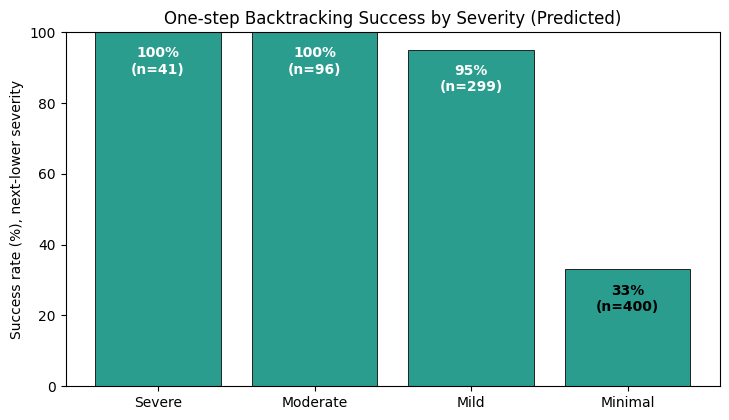

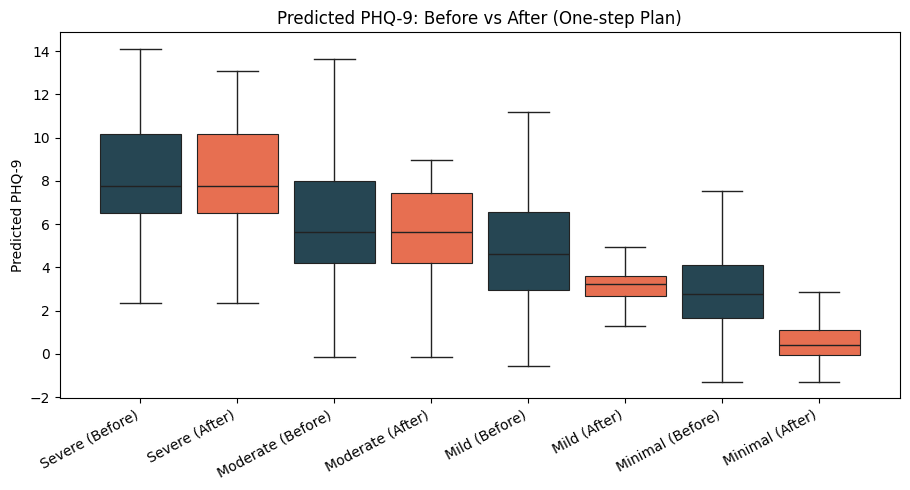

/tmp/ipython-input-810423271.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = plt.boxplot(series3, labels=[k.title() for k in dfs.keys()],


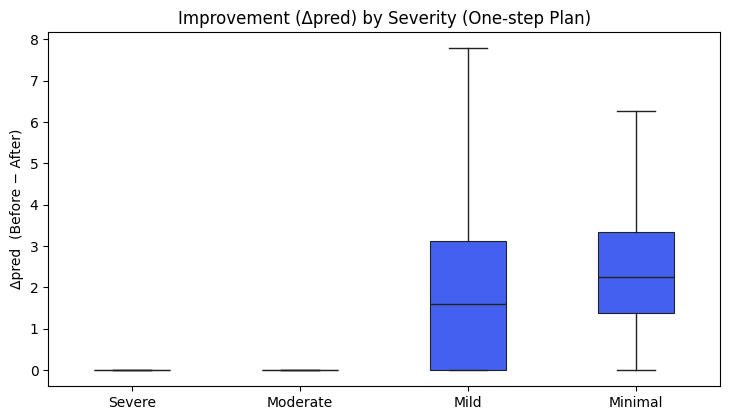

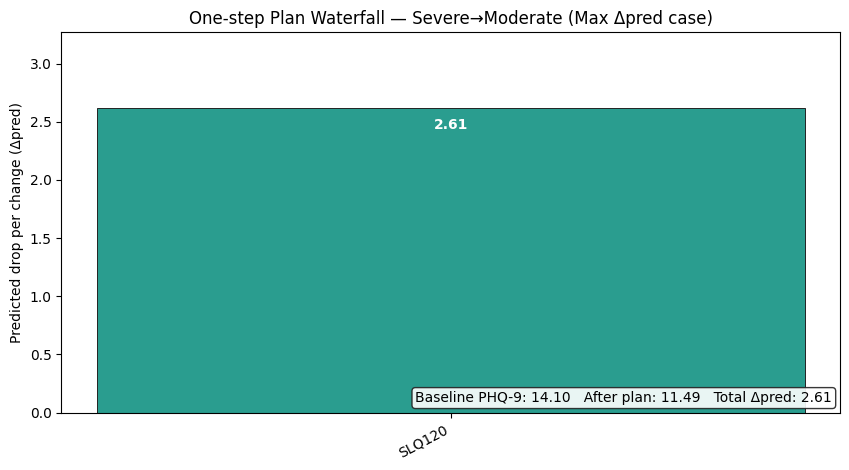

[SAVE] fig_step4_waterfall_severe_example.png, fig_step4_waterfall_severe_example.svg


/tmp/ipython-input-810423271.py:215: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(HEAT_CMAP)


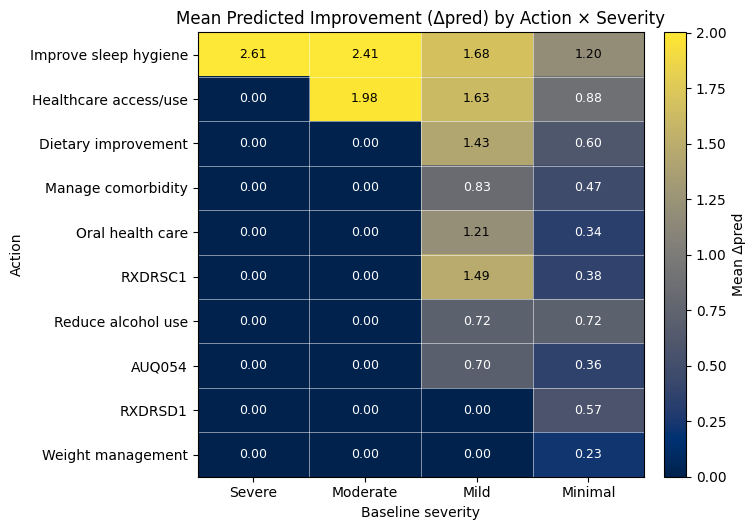

[DONE] Re-rendered, high-contrast figures saved to: /content/mental_outputs/figures_step4


In [ ]:
# =========================================
# Step-4 Figures — High-contrast, color-safe, paper-ready
# =========================================
import os, ast
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap

OUTPUT_DIR = os.environ.get("MENTAL_OUTPUT_DIR", "/content/mental_outputs")
FIG_DIR = Path(OUTPUT_DIR) / "figures_step4"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---- Color settings (color-blind safe) ----
ACCENT      = "#2A9D8F"   # teal
ACCENT_2    = "#E76F51"   # coral
ACCENT_3    = "#264653"   # deep slate
ACCENT_4    = "#4361EE"   # blue for Δpred boxplot
HEAT_CMAP   = "cividis"   # or "viridis" / "plasma"
EDGE        = "#222222"

def load_step4(level):
    p = Path(OUTPUT_DIR)/f"cf_onestep_{level}_to_next.csv"
    if not p.exists(): return None
    df = pd.read_csv(p)
    for c in ["y_pred_before","y_pred_after","target_ceiling","delta_pred"]:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

levels = ["severe","moderate","mild","minimal"]
dfs = {lv: load_step4(lv) for lv in levels if load_step4(lv) is not None}
if not dfs: raise FileNotFoundError("Run Step-4 first (no CSVs found).")

# ---------------- Fig 1: Success by severity (labels inside with auto-contrast) ----------------
names, rates, ns = [], [], []
for lv, df in dfs.items():
    names.append(lv.title())
    rates.append((df["y_pred_after"] <= df["target_ceiling"]).mean()*100.0)
    ns.append(len(df))

plt.figure(figsize=(7.4, 4.3))
x = np.arange(len(names))
bars = plt.bar(x, rates, color=ACCENT, edgecolor=EDGE, linewidth=0.7)
plt.xticks(x, names)
plt.ylim(0, 100)
plt.ylabel("Success rate (%), next-lower severity")
plt.title("One-step Backtracking Success by Severity (Predicted)")
for b, r, n in zip(bars, rates, ns):
    h = b.get_height()
    # auto-contrast text color: white on tall bars, black on small bars
    tcolor = "white" if h >= 60 else "black"
    ytxt = h - 4 if h >= 10 else h + 1
    plt.text(b.get_x()+b.get_width()/2, ytxt, f"{r:.0f}%\n(n={n})",
             ha="center", va="top" if h>=10 else "bottom", color=tcolor, fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR/"fig_step4_success_by_severity.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR/"fig_step4_success_by_severity.svg", bbox_inches="tight")
plt.show()

# ---------------- Fig 2: Before vs After (grouped boxplot, colored) ----------------
labels, series, pos, colors = [], [], [], []
gap = 0.6
for i,(lv,df) in enumerate(dfs.items()):
    bpos, apos = i*2*gap, i*2*gap + gap
    series += [df["y_pred_before"].dropna().values, df["y_pred_after"].dropna().values]
    labels += [f"{lv.title()} (Before)", f"{lv.title()} (After)"]
    pos    += [bpos, apos]
    colors += [ACCENT_3, ACCENT_2]

plt.figure(figsize=(9.2, 5.0))
bp = plt.boxplot(series, positions=pos, widths=0.5, showfliers=False, patch_artist=True)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_edgecolor(EDGE); patch.set_linewidth(0.8)
for elem in ["whiskers","caps","medians"]:
    for artist in bp[elem]: artist.set_color(EDGE)
plt.xticks(pos, labels, rotation=28, ha="right")
plt.ylabel("Predicted PHQ-9")
plt.title("Predicted PHQ-9: Before vs After (One-step Plan)")
plt.tight_layout()
plt.savefig(FIG_DIR/"fig_step4_before_after_boxplot.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR/"fig_step4_before_after_boxplot.svg", bbox_inches="tight")
plt.show()

# ---------------- Fig 3: Δpred by severity (boxplot, colored) ----------------
series3 = [df["delta_pred"].dropna().values for df in dfs.values()]
plt.figure(figsize=(7.4, 4.3))
bp3 = plt.boxplot(series3, labels=[k.title() for k in dfs.keys()],
                  showfliers=False, patch_artist=True)
for patch in bp3["boxes"]:
    patch.set_facecolor(ACCENT_4); patch.set_edgecolor(EDGE); patch.set_linewidth(0.8)
for elem in ["whiskers","caps","medians"]:
    for artist in bp3[elem]: artist.set_color(EDGE)
plt.ylabel("Δpred  (Before − After)")
plt.title("Improvement (Δpred) by Severity (One-step Plan)")
plt.tight_layout()
plt.savefig(FIG_DIR/"fig_step4_delta_by_severity.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR/"fig_step4_delta_by_severity.svg", bbox_inches="tight")
plt.show()

# ---------- PATCH: Waterfall (Severe, max Δpred) — smart labels + headroom ----------
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sv_path = Path(OUTPUT_DIR)/"cf_onestep_severe_to_next.csv"
if sv_path.exists():
    sv = pd.read_csv(sv_path)
    if len(sv):
        row = sv.sort_values("delta_pred", ascending=False).iloc[0]

        # collect steps
        feats, drops = [], []
        j = 1
        while f"chg{j}_feat" in row and pd.notna(row[f"chg{j}_feat"]):
            feats.append(str(row[f"chg{j}_feat"]))
            drops.append(float(row.get(f"chg{j}_drop", 0.0)))
            j += 1

        if drops:
            base  = float(row["y_pred_before"])
            after = float(row["y_pred_after"])
            total = base - after

            fig = plt.figure(figsize=(8.6, 4.8))
            ax  = plt.gca()
            x   = np.arange(len(drops))

            bars = ax.bar(x, drops, color=ACCENT, edgecolor=EDGE, linewidth=0.7)
            ax.set_xticks(x); ax.set_xticklabels(feats, rotation=28, ha="right")
            ax.set_ylabel("Predicted drop per change (Δpred)")
            ax.set_title("One-step Plan Waterfall — Severe→Moderate (Max Δpred case)")

            # --- give vertical headroom so labels never clip ---
            ymax = max(drops) if len(drops) else 1.0
            ax.set_ylim(0, ymax * 1.25)  # 25% headroom

            # --- value labels: inside if tall, otherwise above ---
            for b, d in zip(bars, drops):
                center_x = b.get_x() + b.get_width()/2
                if d >= 0.85 * ax.get_ylim()[1]:  # extremely tall (rare)
                    ax.text(center_x, d - 0.05*ymax, f"{d:.2f}",
                            ha="center", va="top", color="white",
                            fontsize=10, fontweight="bold")
                elif d >= 0.65 * ax.get_ylim()[1]:  # tall: put inside near top
                    ax.text(center_x, d - 0.03*ymax, f"{d:.2f}",
                            ha="center", va="top", color="white",
                            fontsize=10, fontweight="bold")
                else:                               # normal: put slightly above
                    ax.text(center_x, d + 0.03*ymax, f"{d:.2f}",
                            ha="center", va="bottom", color="black",
                            fontsize=10)

            # --- summary box placed top-right inside axes (won't overlap labels) ---
            summary = f"Baseline PHQ-9: {base:.2f}   After plan: {after:.2f}   Total Δpred: {total:.2f}"
            ax.text(0.99, 0.02, summary, transform=ax.transAxes,
                    ha="right", va="bottom", fontsize=10,
                    bbox=dict(facecolor="white", edgecolor=EDGE, alpha=0.9, boxstyle="round,pad=0.25"))

            plt.tight_layout()
            out_png = Path(FIG_DIR)/"fig_step4_waterfall_severe_example.png"
            out_svg = Path(FIG_DIR)/"fig_step4_waterfall_severe_example.svg"
            plt.savefig(out_png, dpi=300, bbox_inches="tight")
            plt.savefig(out_svg, bbox_inches="tight")
            plt.show()
            print(f"[SAVE] {out_png.name}, {out_svg.name}")


# ---------------- Treatment Playbook Heatmap (high-contrast + colorbar) ----------------
all_csv = Path(OUTPUT_DIR)/"cf_onestep_all_levels.csv"
if all_csv.exists():
    df_all = pd.read_csv(all_csv)
    long = []
    for _, r in df_all.iterrows():
        lvl = str(r.get("level_from", "NA"))
        chs = r.get("changes")
        if pd.isna(chs): continue
        try: import ast; changes = ast.literal_eval(chs)
        except Exception: continue
        for ch in changes:
            long.append({"level": lvl,
                         "action": str(ch.get("feature")),
                         "pred_drop": float(ch.get("pred_drop", np.nan))})
    dt = pd.DataFrame(long)
    if len(dt):
        # action label mapping (আপনি চাইলে কাস্টমাইজ করবেন)
        def normalize_action(s):
            u = s.upper()
            if u.startswith("SMQ"): return "Reduce/stop smoking"
            if u.startswith("ALQ"): return "Reduce alcohol use"
            if u.startswith("PAQ"): return "Increase physical activity"
            if u.startswith("SLQ"): return "Improve sleep hygiene"
            if u.startswith("DBQ"): return "Dietary improvement"
            if u.startswith("WHQ"): return "Weight management"
            if u.startswith("RXQ"): return "Medication adherence"
            if u.startswith("MCQ") or u.startswith("HSQ"): return "Manage comorbidity"
            if u.startswith("HUQ") or u.startswith("HEQ"): return "Healthcare access/use"
            if u.startswith("OHQ"): return "Oral health care"
            if u.startswith("BPQ"): return "BP screening/management"
            return s
        dt["action"] = dt["action"].map(normalize_action)

        # টপ-10 অ্যাকশন (মোট Δpred অনুযায়ী)
        top_actions = (dt.groupby("action")["pred_drop"].sum()
                         .sort_values(ascending=False).head(10)).index.tolist()
        levels_order = ["Severe","Moderate","Mild","Minimal"]
        mat = np.zeros((len(top_actions), len(levels_order)))
        for i,a in enumerate(top_actions):
            for j,l in enumerate(levels_order):
                vals = dt[(dt["action"]==a) & (dt["level"]==l)]["pred_drop"].dropna().values
                mat[i,j] = np.mean(vals) if len(vals) else 0.0

        vmax = max(0.01, np.percentile(mat, 95))
        vmin = 0.0
        cmap = get_cmap(HEAT_CMAP)
        norm = Normalize(vmin=vmin, vmax=vmax)

        plt.figure(figsize=(7.6, 5.4))
        im = plt.imshow(mat, aspect="auto", cmap=cmap, norm=norm)
        plt.xticks(np.arange(len(levels_order)), levels_order)
        plt.yticks(np.arange(len(top_actions)), top_actions)
        plt.xlabel("Baseline severity"); plt.ylabel("Action")
        plt.title("Mean Predicted Improvement (Δpred) by Action × Severity")

        # gridlines
        ax = plt.gca()
        ax.set_xticks(np.arange(-.5, len(levels_order), 1), minor=True)
        ax.set_yticks(np.arange(-.5, len(top_actions), 1), minor=True)
        ax.grid(which="minor", color="w", linestyle="-", linewidth=0.6, alpha=0.6)
        ax.tick_params(which="minor", bottom=False, left=False)

        # numeric annotations with auto-contrast
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i,j]
                r,g,b,_ = cmap(norm(val))
                # perceived luminance (YIQ)
                lumin = (0.299*r + 0.587*g + 0.114*b)
                tcol = "black" if lumin > 0.55 else "white"
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=tcol)

        cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
        cbar.set_label("Mean Δpred")
        plt.tight_layout()
        plt.savefig(FIG_DIR/"fig_step4_treatment_heatmap.png", dpi=300, bbox_inches="tight")
        plt.savefig(FIG_DIR/"fig_step4_treatment_heatmap.svg", bbox_inches="tight")
        plt.show()

print(f"[DONE] Re-rendered, high-contrast figures saved to: {FIG_DIR}")


Using output dir: /content/mental_outputs

— Domain mapping (expert-defined) —


,module,domain
0,DEMO,socio-demographic
1,INQ,socio-demographic
2,HIQ,socio-demographic
3,OCQ,socio-demographic
4,FSQ,socio-demographic
5,ALQ,behavioral-lifestyle
6,SMQ,behavioral-lifestyle
7,PAQ,behavioral-lifestyle
8,SLQ,behavioral-lifestyle
9,DBQ,behavioral-lifestyle



— Groupwise ranked features (full, top by causal score) —


,feature_base,shap_importance,domain,group_rel
0,SLQ050,0.770514,behavioral-lifestyle,0.254919
1,SLQ120,0.629197,behavioral-lifestyle,0.208165
65,HUQ010,0.472275,clinical-health,0.242111
66,HUQ090,0.265755,clinical-health,0.136239
67,MCQ520,0.239529,clinical-health,0.122794
129,KIQ044,0.193821,other,0.152985
177,RIDAGEYR,0.174792,socio-demographic,0.196453
2,DBQ700,0.168304,behavioral-lifestyle,0.055682
130,KIQ042,0.159175,other,0.125638
131,KIQ480,0.151132,other,0.119289



— Groupwise pruned features (threshold + Top-K) —


...

,fitness,r2,mae,n_features
0,0.303386,0.366386,2.383805,46



— GA selected domains (flag) —


,domain,selected_by_GA
0,behavioral-lifestyle,1
1,clinical-health,1
2,other,1
3,socio-demographic,1



— Final domain priority table —


,domain,perm_importance,selected_by_GA
0,behavioral-lifestyle,0.126575,1
1,clinical-health,0.118278,1
2,socio-demographic,0.080833,1
3,other,0.004278,1


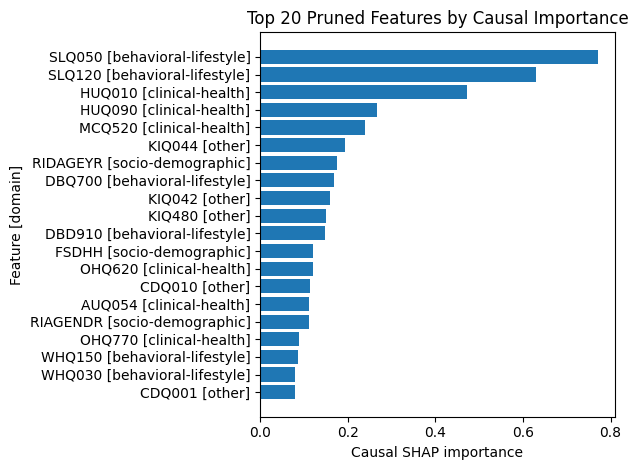

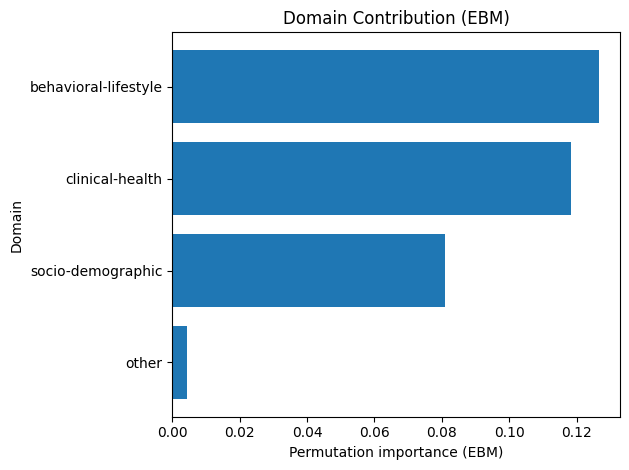

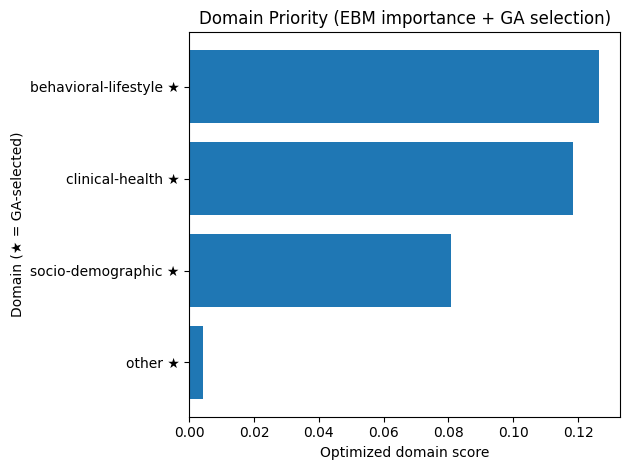


Saved figures to: /content/mental_outputs


In [ ]:
# === View artifacts as tables + graphs ===
import os, json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1) Auto-detect output directory
CANDS = ["/content/mental_outputs", "/content/drive/MyDrive/mental_outputs"]
OUT_DIR = next((p for p in CANDS if os.path.isdir(p)), None)
if OUT_DIR is None:
    raise FileNotFoundError("Couldn't find mental_outputs. Run the pipeline first.")
print("Using output dir:", OUT_DIR)

# 2) Load artifacts
mapping_path = Path(OUT_DIR)/"domain_mapping.json"
rank_path    = Path(OUT_DIR)/"groupwise_ranked_features_full.csv"
prune_path   = Path(OUT_DIR)/"groupwise_pruned_features.csv"
domimp_path  = Path(OUT_DIR)/"domain_importance_ebm.csv"
gapath       = Path(OUT_DIR)/"ga_domain_selection.json"
prior_path   = Path(OUT_DIR)/"domain_priority_final.csv"

domain_map = json.load(open(mapping_path))
map_df = pd.DataFrame(list(domain_map.items()), columns=["module","domain"])

rank_df   = pd.read_csv(rank_path)
pruned_df = pd.read_csv(prune_path)
dom_imp   = pd.read_csv(domimp_path)
priority  = pd.read_csv(prior_path)

ga = json.load(open(gapath))
ga_meta = pd.DataFrame([{
    "fitness": ga.get("fitness"),
    "r2": ga.get("r2"),
    "mae": ga.get("mae"),
    "n_features": ga.get("n_features")
}])
ga_sel = pd.DataFrame({"domain": ga.get("domain_list", [])})
ga_sel["selected_by_GA"] = ga_sel["domain"].isin(ga.get("best_domains", [])).astype(int)

# 3) Show tables (previews)
print("\n— Domain mapping (expert-defined) —")
display(map_df.head(30))

print("\n— Groupwise ranked features (full, top by causal score) —")
display(rank_df.sort_values("shap_importance", ascending=False).head(25))

print("\n— Groupwise pruned features (threshold + Top-K) —")
display(pruned_df.sort_values(["domain","shap_importance"], ascending=[True,False]).head(25))

print("\n— Domain importance (EBM permutation-aggregate) —")
display(dom_imp.sort_values("perm_importance", ascending=False))

print("\n— GA domain selection (meta) —")
display(ga_meta)
print("\n— GA selected domains (flag) —")
display(ga_sel)

print("\n— Final domain priority table —")
display(priority.sort_values("perm_importance", ascending=False))

# 4) Graphs (saved + shown). One plot per figure; no custom colors/styles.
viz_dir = Path(OUT_DIR)
viz_dir.mkdir(exist_ok=True, parents=True)

# (A) Top 20 pruned features by causal importance
tp = pruned_df.sort_values("shap_importance", ascending=False).head(20).copy()
tp["label"] = tp["feature_base"] + " [" + tp["domain"] + "]"
plt.figure()
plt.barh(tp["label"][::-1], tp["shap_importance"][::-1])
plt.xlabel("Causal SHAP importance")
plt.ylabel("Feature [domain]")
plt.title("Top 20 Pruned Features by Causal Importance")
plt.tight_layout()
plt.savefig(viz_dir/"viz_top_pruned_features.png", dpi=200)
plt.show()

# (B) Domain contribution from EBM (permutation importance)
di = dom_imp.sort_values("perm_importance", ascending=False)
plt.figure()
plt.barh(di["domain"][::-1], di["perm_importance"][::-1])
plt.xlabel("Permutation importance (EBM)")
plt.ylabel("Domain")
plt.title("Domain Contribution (EBM)")
plt.tight_layout()
plt.savefig(viz_dir/"viz_domain_importance_ebm.png", dpi=200)
plt.show()

# (C) Final domain priority (EBM importance + GA selection flag)
dp = priority.sort_values("perm_importance", ascending=False).copy()
dp["label"] = dp["domain"] + dp["selected_by_GA"].map({1:" ★", 0:""})
plt.figure()
plt.barh(dp["label"][::-1], dp["perm_importance"][::-1])
plt.xlabel("Optimized domain score")
plt.ylabel("Domain (★ = GA-selected)")
plt.title("Domain Priority (EBM importance + GA selection)")
plt.tight_layout()
plt.savefig(viz_dir/"viz_domain_priority_final.png", dpi=200)
plt.show()

print("\nSaved figures to:", viz_dir)
